# YOLO OCR LiLT Invoice KIE

This notebook runs the local YOLO text detector, saves text crops, OCRs those crops,
feeds OCR tokens and layout boxes into the fine-tuned LiLT model, and draws the
extracted key-information boxes on the original invoice image.

In [2]:
%pip install safetensors transformers ultralytics

Defaulting to user installation because normal site-packages is not writeable
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached ultralytics-8.4.56-py3-none-any.whl.metadata (39 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached hf_xet-1.5.0-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (4.9 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached polars-1.41.1-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.19-py3-none-any.whl.metadata (14 kB)
  Using cached polars_runtime_32-1.41.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.5 kB)
Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (507 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 

In [3]:
from importlib.util import find_spec

required_packages = {
    "cv2": "opencv-python",
    "easyocr": "easyocr",
    "numpy": "numpy",
    "pandas": "pandas",
    "PIL": "Pillow",
    "safetensors": "safetensors",
    "torch": "torch",
    "transformers": "transformers",
    "ultralytics": "ultralytics",
}

missing = [
    package
    for module, package in required_packages.items()
    if find_spec(module) is None
]

if missing:
    print("Missing packages. Run this in a notebook cell, then restart the kernel:")
    print("%pip install " + " ".join(missing))
else:
    print("All notebook dependencies found.")

All notebook dependencies found.


In [36]:
from __future__ import annotations

import hashlib
import json
import re
from collections import defaultdict
from pathlib import Path

import cv2
import easyocr
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from transformers import AutoModelForTokenClassification, AutoTokenizer
from ultralytics import YOLO

ROOT = Path.cwd()
YOLO_MODEL_PATH = ROOT / "yolo26_text-detection.pt"
LILT_MODEL_PATH = ROOT / "lilt_arabic_best"

#default_image = ROOT / "real_invoices" / "images" / "real_invoice_03.png"
default_image = ROOT / "local_test_2.png"
if not default_image.exists():
    candidates = sorted(
        list(ROOT.rglob("*.png"))
        + list(ROOT.rglob("*.jpg"))
        + list(ROOT.rglob("*.jpeg"))
    )
    default_image = candidates[0] if candidates else ROOT / "invoice.png"

IMAGE_PATH = default_image
OUTPUT_DIR = ROOT / "yolo_ocr_lilt_output"
CROP_DIR = OUTPUT_DIR / "crops" / IMAGE_PATH.stem

PREPROCESS_MODE = "enhance"  # "none", "enhance", or "threshold"
READING_DIRECTION = "rtl"    # Arabic invoices usually read right-to-left within each line
YOLO_CONF = 0.10
YOLO_IOU = 0.60
YOLO_IMGSZ = 1280
CROP_PADDING = 3
MIN_OCR_CONFIDENCE = 0.05
MAX_SEQ_LENGTH = 512

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CROP_DIR.mkdir(parents=True, exist_ok=True)

print(f"Image      : {IMAGE_PATH}")
print(f"YOLO model : {YOLO_MODEL_PATH}")
print(f"LiLT model : {LILT_MODEL_PATH}")
print(f"Device     : {DEVICE}")

if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Set IMAGE_PATH to an existing invoice image: {IMAGE_PATH}")
if not YOLO_MODEL_PATH.exists():
    raise FileNotFoundError(f"YOLO model not found: {YOLO_MODEL_PATH}")
if not LILT_MODEL_PATH.exists():
    raise FileNotFoundError(f"LiLT model folder not found: {LILT_MODEL_PATH}")

Image      : /var/home/abdelhak/study/arabic_invoice_generator/local_test_2.png
YOLO model : /var/home/abdelhak/study/arabic_invoice_generator/yolo26_text-detection.pt
LiLT model : /var/home/abdelhak/study/arabic_invoice_generator/lilt_arabic_best
Device     : cpu


## Utility Functions

In [37]:
def read_image_bgr(image_path: Path) -> np.ndarray:
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    return image_bgr


def preprocess_invoice(image_bgr: np.ndarray, mode: str = "enhance") -> np.ndarray:
    if mode == "none":
        return image_bgr.copy()

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    if mode == "enhance":
        denoised = cv2.bilateralFilter(enhanced, d=5, sigmaColor=35, sigmaSpace=35)
        return cv2.cvtColor(denoised, cv2.COLOR_GRAY2BGR)

    if mode == "threshold":
        denoised = cv2.GaussianBlur(enhanced, (3, 3), 0)
        binary = cv2.adaptiveThreshold(
            denoised,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            11,
            2,
        )
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
        closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)
        return cv2.cvtColor(closed, cv2.COLOR_GRAY2BGR)

    raise ValueError(f"Unsupported preprocessing mode: {mode}")


def clip_bbox_xyxy(bbox: list[int] | tuple[int, int, int, int], width: int, height: int) -> list[int]:
    x1, y1, x2, y2 = [int(round(v)) for v in bbox]
    x1 = max(0, min(width - 1, x1))
    y1 = max(0, min(height - 1, y1))
    x2 = max(0, min(width - 1, x2))
    y2 = max(0, min(height - 1, y2))
    if x2 < x1:
        x1, x2 = x2, x1
    if y2 < y1:
        y1, y2 = y2, y1
    return [x1, y1, x2, y2]


def normalize_bbox_xyxy(bbox: list[int], width: int, height: int) -> list[int]:
    x1, y1, x2, y2 = bbox
    return [
        max(0, min(1000, int(round(1000 * x1 / width)))),
        max(0, min(1000, int(round(1000 * y1 / height)))),
        max(0, min(1000, int(round(1000 * x2 / width)))),
        max(0, min(1000, int(round(1000 * y2 / height)))),
    ]


def bbox_union(boxes: list[list[int]]) -> list[int]:
    arr = np.array(boxes, dtype=np.int32)
    x1, y1 = arr[:, :2].min(axis=0)
    x2, y2 = arr[:, 2:].max(axis=0)
    return [int(x1), int(y1), int(x2), int(y2)]


def bbox_iou(a: list[int], b: list[int]) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union else 0.0


def contains_arabic(text: str) -> bool:
    return any("\u0600" <= ch <= "\u06ff" for ch in text)


def class_name(names, class_id: int) -> str:
    if isinstance(names, dict):
        return str(names.get(class_id, class_id))
    if 0 <= class_id < len(names):
        return str(names[class_id])
    return str(class_id)

## YOLO Text Detection

YOLO detections: 158
Saved preprocessed image: /var/home/abdelhak/study/arabic_invoice_generator/yolo_ocr_lilt_output/local_test_2_preprocessed.jpg
Saved detection image   : /var/home/abdelhak/study/arabic_invoice_generator/yolo_ocr_lilt_output/local_test_2_yolo_detections.jpg


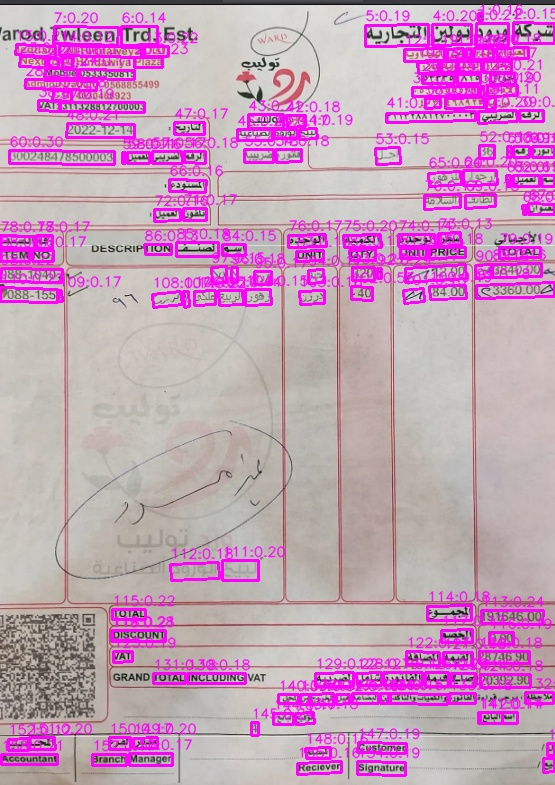

In [38]:
def extract_yolo_detections(result, width: int, height: int) -> list[dict]:
    detections = []

    boxes = getattr(result, "boxes", None)
    if boxes is not None and len(boxes) > 0:
        xyxy = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy()
        classes = boxes.cls.cpu().numpy().astype(int)
        for idx, box in enumerate(xyxy):
            class_id = int(classes[idx])
            detections.append(
                {
                    "detection_id": f"det_{idx:04d}",
                    "bbox": clip_bbox_xyxy(box.tolist(), width, height),
                    "confidence": float(confs[idx]),
                    "class_id": class_id,
                    "class_name": class_name(result.names, class_id),
                    "type": "box",
                }
            )

    obb = getattr(result, "obb", None)
    if obb is not None and len(obb) > 0:
        polygons = obb.xyxyxyxy.cpu().numpy()
        confs = obb.conf.cpu().numpy()
        classes = obb.cls.cpu().numpy().astype(int)
        start_idx = len(detections)
        for rel_idx, polygon in enumerate(polygons):
            polygon = polygon.reshape(4, 2)
            polygon[:, 0] = np.clip(polygon[:, 0], 0, width - 1)
            polygon[:, 1] = np.clip(polygon[:, 1], 0, height - 1)
            x1, y1 = polygon.min(axis=0)
            x2, y2 = polygon.max(axis=0)
            class_id = int(classes[rel_idx])
            detections.append(
                {
                    "detection_id": f"det_{start_idx + rel_idx:04d}",
                    "bbox": clip_bbox_xyxy([x1, y1, x2, y2], width, height),
                    "polygon": polygon.round().astype(int).tolist(),
                    "confidence": float(confs[rel_idx]),
                    "class_id": class_id,
                    "class_name": class_name(result.names, class_id),
                    "type": "obb",
                }
            )

    return detections


def sort_by_reading_order(items: list[dict], direction: str = "rtl", y_tolerance: int | None = None) -> list[dict]:
    if not items:
        return []

    heights = [max(1, item["bbox"][3] - item["bbox"][1]) for item in items]
    tolerance = y_tolerance if y_tolerance is not None else max(8, int(np.median(heights) * 0.60))

    def center_y(item):
        return (item["bbox"][1] + item["bbox"][3]) / 2

    def center_x(item):
        return (item["bbox"][0] + item["bbox"][2]) / 2

    lines = []
    for item in sorted(items, key=lambda value: (center_y(value), center_x(value))):
        cy = center_y(item)
        for line in lines:
            if abs(cy - line["cy"]) <= tolerance:
                line["items"].append(item)
                line["cy"] = float(np.mean([center_y(line_item) for line_item in line["items"]]))
                break
        else:
            lines.append({"cy": cy, "items": [item]})

    ordered = []
    for line in sorted(lines, key=lambda value: value["cy"]):
        reverse = direction.lower() == "rtl"
        ordered.extend(sorted(line["items"], key=center_x, reverse=reverse))

    return ordered


def draw_detection_boxes(image_bgr: np.ndarray, detections: list[dict], output_path: Path) -> np.ndarray:
    canvas = image_bgr.copy()
    for idx, det in enumerate(detections, start=1):
        x1, y1, x2, y2 = det["bbox"]
        color = (0, 0, 255) if det["type"] == "box" else (255, 0, 255)
        if "polygon" in det:
            polygon = np.array(det["polygon"], dtype=np.int32).reshape((-1, 1, 2))
            cv2.polylines(canvas, [polygon], isClosed=True, color=color, thickness=2)
        else:
            cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)

        label = f"{idx}:{det['confidence']:.2f}"
        cv2.putText(
            canvas,
            label,
            (x1, max(14, y1 - 4)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            color,
            1,
            cv2.LINE_AA,
        )

    cv2.imwrite(str(output_path), canvas)
    return canvas


image_bgr = read_image_bgr(IMAGE_PATH)
image_height, image_width = image_bgr.shape[:2]
preprocessed_bgr = preprocess_invoice(image_bgr, PREPROCESS_MODE)

preprocessed_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_preprocessed.jpg"
cv2.imwrite(str(preprocessed_path), preprocessed_bgr)

yolo_model = YOLO(str(YOLO_MODEL_PATH))
predict_kwargs = {
    "source": preprocessed_bgr,
    "conf": YOLO_CONF,
    "iou": YOLO_IOU,
    "imgsz": YOLO_IMGSZ,
    "verbose": False,
}
if DEVICE == "cuda":
    predict_kwargs["device"] = 0
else:
    predict_kwargs["device"] = "cpu"

yolo_result = yolo_model.predict(**predict_kwargs)[0]
detections = extract_yolo_detections(yolo_result, image_width, image_height)
detections = sort_by_reading_order(detections, READING_DIRECTION)

detection_json_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_yolo_detections.json"
detection_vis_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_yolo_detections.jpg"

with detection_json_path.open("w", encoding="utf-8") as file:
    json.dump(detections, file, ensure_ascii=False, indent=2)

draw_detection_boxes(image_bgr, detections, detection_vis_path)

print(f"YOLO detections: {len(detections)}")
print(f"Saved preprocessed image: {preprocessed_path}")
print(f"Saved detection image   : {detection_vis_path}")
display(Image.open(detection_vis_path))

## Crop Detected Text and OCR

In [39]:
def crop_with_padding(image_bgr: np.ndarray, bbox: list[int], padding: int = 4):
    height, width = image_bgr.shape[:2]
    x1, y1, x2, y2 = bbox
    padded = clip_bbox_xyxy(
        [x1 - padding, y1 - padding, x2 + padding, y2 + padding],
        width,
        height,
    )
    px1, py1, px2, py2 = padded
    return image_bgr[py1:py2 + 1, px1:px2 + 1], (px1, py1), padded


def prepare_crop_for_ocr(crop_bgr: np.ndarray):
    if crop_bgr.size == 0:
        return crop_bgr, 1.0, 1.0

    height, width = crop_bgr.shape[:2]
    scale = 1
    if min(height, width) < 48:
        scale = 2
    if max(height, width) < 160:
        scale = max(scale, 2)
    if scale > 1:
        crop_bgr = cv2.resize(
            crop_bgr,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_CUBIC,
        )

    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    scale_x = width / max(1, enhanced.shape[1])
    scale_y = height / max(1, enhanced.shape[0])
    return enhanced, scale_x, scale_y


def polygon_to_xyxy(points) -> list[int]:
    arr = np.array(points, dtype=np.float32).reshape(-1, 2)
    x1, y1 = arr.min(axis=0)
    x2, y2 = arr.max(axis=0)
    return [int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))]


def clean_ocr_text(text: str) -> str:
    return re.sub(r"\s+", " ", str(text)).strip()


def split_text_into_token_boxes(text: str, bbox: list[int]) -> list[tuple[str, list[int]]]:
    pieces = [piece for piece in re.split(r"\s+", clean_ocr_text(text)) if piece]
    if not pieces:
        return []
    if len(pieces) == 1:
        return [(pieces[0], bbox)]

    x1, y1, x2, y2 = bbox
    width = max(1, x2 - x1)
    weights = np.array([max(1, len(piece)) for piece in pieces], dtype=np.float32)
    weights = weights / weights.sum()

    token_boxes = []
    if contains_arabic(text):
        cursor = float(x2)
        for piece, weight in zip(pieces, weights):
            token_width = float(width * weight)
            part_x1 = cursor - token_width
            token_boxes.append((piece, [round(part_x1), y1, round(cursor), y2]))
            cursor = part_x1
    else:
        cursor = float(x1)
        for piece, weight in zip(pieces, weights):
            token_width = float(width * weight)
            part_x2 = cursor + token_width
            token_boxes.append((piece, [round(cursor), y1, round(part_x2), y2]))
            cursor = part_x2

    return token_boxes


def deduplicate_ocr_tokens(tokens: list[dict], iou_threshold: float = 0.80) -> list[dict]:
    kept = []
    for token in sorted(tokens, key=lambda value: value["ocr_confidence"], reverse=True):
        duplicate = False
        for existing in kept:
            if token["text"] == existing["text"] and bbox_iou(token["bbox"], existing["bbox"]) >= iou_threshold:
                duplicate = True
                break
        if not duplicate:
            kept.append(token)
    return sort_by_reading_order(kept, READING_DIRECTION)


ocr_reader = easyocr.Reader(["ar", "en"], gpu=(DEVICE == "cuda"))
ocr_tokens = []

for det_idx, detection in enumerate(detections):
    crop_bgr, (offset_x, offset_y), padded_bbox = crop_with_padding(
        image_bgr,
        detection["bbox"],
        CROP_PADDING,
    )
    if crop_bgr.size == 0:
        continue

    crop_path = CROP_DIR / f"{IMAGE_PATH.stem}_crop_{det_idx:04d}.jpg"
    cv2.imwrite(str(crop_path), crop_bgr)

    crop_gray, scale_x, scale_y = prepare_crop_for_ocr(crop_bgr)
    crop_h, crop_w = crop_gray.shape[:2]

    recognized = ocr_reader.recognize(
        crop_gray,
        horizontal_list=[[0, crop_w, 0, crop_h]],
        free_list=[],
        detail=1,
        paragraph=False,
    )

    ocr_items = []
    if recognized:
        _, text, confidence = recognized[0]
        text = clean_ocr_text(text)
        confidence = float(confidence)
        if text and confidence >= MIN_OCR_CONFIDENCE:
            ocr_items.append((text, confidence, detection["bbox"]))

    if not ocr_items:
        fallback_results = ocr_reader.readtext(crop_gray, detail=1, paragraph=False)
        for local_polygon, text, confidence in fallback_results:
            text = clean_ocr_text(text)
            confidence = float(confidence)
            if not text or confidence < MIN_OCR_CONFIDENCE:
                continue

            local_bbox = polygon_to_xyxy(local_polygon)
            local_bbox = [
                int(round(local_bbox[0] * scale_x)),
                int(round(local_bbox[1] * scale_y)),
                int(round(local_bbox[2] * scale_x)),
                int(round(local_bbox[3] * scale_y)),
            ]
            global_bbox = clip_bbox_xyxy(
                [
                    local_bbox[0] + offset_x,
                    local_bbox[1] + offset_y,
                    local_bbox[2] + offset_x,
                    local_bbox[3] + offset_y,
                ],
                image_width,
                image_height,
            )
            ocr_items.append((text, confidence, global_bbox))

    for text, ocr_confidence, global_bbox in ocr_items:
        for token_text, token_bbox in split_text_into_token_boxes(text, global_bbox):
            token_bbox = clip_bbox_xyxy(token_bbox, image_width, image_height)
            ocr_tokens.append(
                {
                    "text": token_text,
                    "bbox": token_bbox,
                    "bbox_norm": normalize_bbox_xyxy(token_bbox, image_width, image_height),
                    "ocr_confidence": float(ocr_confidence),
                    "detection_confidence": float(detection["confidence"]),
                    "detection_id": detection["detection_id"],
                    "crop_path": str(crop_path),
                }
            )

ocr_tokens = deduplicate_ocr_tokens(ocr_tokens)

ocr_json_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_ocr_tokens.json"
with ocr_json_path.open("w", encoding="utf-8") as file:
    json.dump(ocr_tokens, file, ensure_ascii=False, indent=2)

print(f"OCR tokens: {len(ocr_tokens)}")
print(f"Saved crops under: {CROP_DIR}")
print(f"Saved OCR tokens : {ocr_json_path}")

pd.DataFrame(ocr_tokens).head(40)

Using CPU. Note: This module is much faster with a GPU.


OCR tokens: 178
Saved crops under: /var/home/abdelhak/study/arabic_invoice_generator/yolo_ocr_lilt_output/crops/local_test_2
Saved OCR tokens : /var/home/abdelhak/study/arabic_invoice_generator/yolo_ocr_lilt_output/local_test_2_ocr_tokens.json


,text,bbox,bbox_norm,ocr_confidence,detection_confidence,detection_id,crop_path
0,.,"[478, 13, 482, 20]","[861, 17, 868, 25]",0.134319,0.158023,det_0119,/var/home/abdelhak/study/arabic_invoice_genera...
1,شركة,"[513, 22, 554, 43]","[924, 28, 998, 55]",0.996361,0.154357,det_0123,/var/home/abdelhak/study/arabic_invoice_genera...
2,ورود,"[475, 23, 508, 45]","[856, 29, 915, 57]",0.985469,0.213386,det_0019,/var/home/abdelhak/study/arabic_invoice_genera...
3,تولين,"[432, 24, 471, 45]","[778, 31, 849, 57]",0.995792,0.195694,det_0039,/var/home/abdelhak/study/arabic_invoice_genera...
4,التجارية,"[365, 24, 428, 46]","[658, 31, 771, 59]",0.888948,0.185347,det_0053,/var/home/abdelhak/study/arabic_invoice_genera...
5,Trd.,"[121, 26, 157, 45]","[218, 33, 283, 57]",0.590619,0.138528,det_0141,/var/home/abdelhak/study/arabic_invoice_genera...
6,Twleen,"[53, 26, 118, 45]","[95, 33, 213, 57]",0.844109,0.198992,det_0032,/var/home/abdelhak/study/arabic_invoice_genera...
7,العنوان,"[500, 47, 528, 59]","[901, 60, 951, 75]",0.610357,0.180233,det_0067,/var/home/abdelhak/study/arabic_invoice_genera...
8,",","[496, 47, 500, 59]","[894, 60, 901, 75]",0.610357,0.180233,det_0067,/var/home/abdelhak/study/arabic_invoice_genera...
9,جدة,"[473, 48, 493, 59]","[852, 61, 888, 75]",0.774685,0.211006,det_0022,/var/home/abdelhak/study/arabic_invoice_genera...


## LiLT Key Information Extraction

In [40]:
def run_lilt_token_classification(ocr_tokens: list[dict]) -> list[dict]:
    if not ocr_tokens:
        return []

    tokens = [item["text"] for item in ocr_tokens]
    boxes = [item["bbox_norm"] for item in ocr_tokens]

    tokenizer = AutoTokenizer.from_pretrained(
        str(LILT_MODEL_PATH),
        use_fast=False,
        local_files_only=True,
    )
    model = AutoModelForTokenClassification.from_pretrained(
        str(LILT_MODEL_PATH),
        local_files_only=True,
    ).to(DEVICE)
    model.eval()

    encoding = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=MAX_SEQ_LENGTH,
    )

    word_ids = encoding.word_ids(batch_index=0)
    aligned_boxes = []
    for word_id in word_ids:
        if word_id is None:
            aligned_boxes.append([0, 0, 0, 0])
        else:
            aligned_boxes.append(boxes[word_id])

    model_inputs = {name: tensor.to(DEVICE) for name, tensor in encoding.items()}
    model_inputs["bbox"] = torch.tensor([aligned_boxes], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        outputs = model(**model_inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1)[0].detach().cpu()
        predicted_ids = probabilities.argmax(dim=-1).tolist()

    id2label = {int(key): value for key, value in model.config.id2label.items()}

    seen_word_ids = set()
    predictions = []
    for token_idx, word_id in enumerate(word_ids):
        if word_id is None or word_id in seen_word_ids or word_id >= len(ocr_tokens):
            continue
        seen_word_ids.add(word_id)
        label_id = int(predicted_ids[token_idx])
        label = id2label.get(label_id, str(label_id))
        score = float(probabilities[token_idx, label_id])
        predictions.append(
            {
                **ocr_tokens[word_id],
                "label": label,
                "lilt_score": score,
                "token_index": word_id,
            }
        )

    if len(seen_word_ids) < len(tokens):
        print(
            f"LiLT used {len(seen_word_ids)} of {len(tokens)} OCR tokens. "
            "Increase MAX_SEQ_LENGTH or split long documents if needed."
        )

    return predictions


def bio_to_field(label: str):
    if label == "O" or "-" not in label:
        return None, None
    prefix, field = label.split("-", 1)
    return prefix, field


def merge_bio_entities(predictions: list[dict]) -> list[dict]:
    entities = []
    current = None

    def close_current():
        nonlocal current
        if current is None:
            return
        current["text"] = " ".join(current.pop("tokens"))
        current["bbox"] = bbox_union(current.pop("boxes"))
        current["bbox_norm"] = normalize_bbox_xyxy(current["bbox"], image_width, image_height)
        current["score"] = float(np.mean(current.pop("scores")))
        entities.append(current)
        current = None

    for prediction in predictions:
        prefix, field = bio_to_field(prediction["label"])
        if field is None:
            close_current()
            continue

        starts_new = prefix == "B" or current is None or current["field"] != field
        if starts_new:
            close_current()
            current = {
                "field": field,
                "tokens": [prediction["text"]],
                "boxes": [prediction["bbox"]],
                "scores": [prediction["lilt_score"]],
                "token_indices": [prediction["token_index"]],
            }
        else:
            current["tokens"].append(prediction["text"])
            current["boxes"].append(prediction["bbox"])
            current["scores"].append(prediction["lilt_score"])
            current["token_indices"].append(prediction["token_index"])

    close_current()
    return entities


lilt_predictions = run_lilt_token_classification(ocr_tokens)
entities = merge_bio_entities(lilt_predictions)

fields = defaultdict(list)
for entity in entities:
    fields[entity["field"]].append(
        {
            "text": entity["text"],
            "bbox": entity["bbox"],
            "score": entity["score"],
        }
    )

result_payload = {
    "image": str(IMAGE_PATH),
    "model": str(LILT_MODEL_PATH),
    "fields": dict(fields),
    "entities": entities,
    "token_predictions": lilt_predictions,
}

result_json_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_lilt_kie_results.json"
with result_json_path.open("w", encoding="utf-8") as file:
    json.dump(result_payload, file, ensure_ascii=False, indent=2)

print(f"LiLT entity count: {len(entities)}")
print(f"Saved KIE JSON  : {result_json_path}")

entity_table = pd.DataFrame(
    [
        {
            "field": entity["field"],
            "text": entity["text"],
            "score": round(entity["score"], 4),
            "bbox": entity["bbox"],
        }
        for entity in entities
    ]
)
entity_table

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [00:00<00:00, 12523.49it/s]


LiLT entity count: 36
Saved KIE JSON  : /var/home/abdelhak/study/arabic_invoice_generator/yolo_ocr_lilt_output/local_test_2_lilt_kie_results.json


,field,text,score,bbox
0,WEBSITE,.,0.8466,"[478, 13, 482, 20]"
1,SELLER_NAME,التجارية,0.3222,"[365, 24, 428, 46]"
2,COMPANY_NAME,-,0.9435,"[466, 49, 471, 58]"
3,WEBSITE,.,0.6972,"[59, 45, 66, 57]"
4,SELLER_VAT,٠٨١٥,0.6044,"[457, 74, 480, 83]"
5,SELLER_VAT,٠٥٣٣٣٥,0.9708,"[422, 74, 454, 83]"
6,SELLER_PHONE,0533350615,0.7988,"[79, 69, 134, 79]"
7,WEBSITE,",",0.4389,"[480, 86, 484, 96]"
8,SELLER_VAT,٠٥٦٨٨٥٥،٩٩,0.9729,"[412, 86, 478, 96]"
9,CASHIER_ID,:311328812700001,0.3812,"[60, 102, 144, 112]"


## Draw Extracted Field Boxes

Saved annotated result: /var/home/abdelhak/study/arabic_invoice_generator/yolo_ocr_lilt_output/local_test_2_lilt_fields.jpg


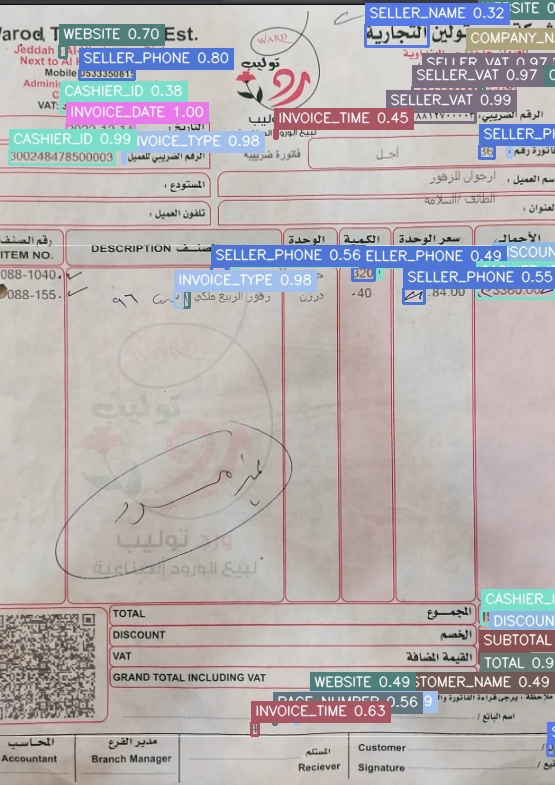

In [41]:
def field_color(field: str) -> tuple[int, int, int]:
    digest = hashlib.md5(field.encode("utf-8")).digest()
    return tuple(int(60 + channel % 180) for channel in digest[:3])


def draw_lilt_entities(image_bgr: np.ndarray, entities: list[dict], output_path: Path) -> np.ndarray:
    canvas = image_bgr.copy()

    for entity in entities:
        x1, y1, x2, y2 = entity["bbox"]
        color = field_color(entity["field"])
        label = f"{entity['field']} {entity['score']:.2f}"

        cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)

        (label_w, label_h), baseline = cv2.getTextSize(
            label,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            1,
        )
        label_y1 = max(0, y1 - label_h - baseline - 6)
        label_y2 = max(label_h + baseline + 4, y1)
        cv2.rectangle(
            canvas,
            (x1, label_y1),
            (min(image_width - 1, x1 + label_w + 8), label_y2),
            color,
            thickness=-1,
        )
        cv2.putText(
            canvas,
            label,
            (x1 + 4, label_y2 - baseline - 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )

    cv2.imwrite(str(output_path), canvas)
    return canvas


annotated_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_lilt_fields.jpg"
draw_lilt_entities(image_bgr, entities, annotated_path)

print(f"Saved annotated result: {annotated_path}")
display(Image.open(annotated_path))